# 严格 Holdout +6dB 主目标实现与可视化报告

本 Notebook 作为最终验收页，统一读取外部实验结果（train/eval artifacts）进行可视化与 Gate。

当前主目标口径：
- 在 strict holdout 下（test split + warmstart level=3 + early_window_s=0.25s），
- 主验收指标为 early_gain_db_mean >= 6.0 dB（相对 Zero-init），
- sample_6db_pass_rate 作为稳定性监控项。

Notebook 结构：
1. 数据集加载与 strict split 可视化（基准 Zero-init / W_full-init）
2. 外部实验结果同步与训练历史可视化（history.csv）
3. 测试可视化与统计（外部 checkpoint 房间曲线 + 外部 eval 汇总）
4. Split 硬审计与 Notebook Gate（最终发布门槛）

说明：
- 本 Notebook 不在内部重新训练模型，避免与最终 gate 数据源不一致。
- 所有展示和最终判定都来自同一外部实验目录与配置。
- 只有 Notebook Gate 通过，才视为最终通过。

In [12]:
# 环境与依赖
# 如果缺少依赖，请取消下一行注释执行
# %pip install numpy matplotlib h5py torch

from __future__ import annotations

import csv
import json
import math
import sys
from pathlib import Path
from typing import Any

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import display
from torch.utils.data import DataLoader

print("numpy:", np.__version__)
print("torch:", torch.__version__)
print("h5py:", h5py.__version__)

numpy: 1.26.4
torch: 2.4.0
h5py: 3.16.0


In [13]:
# 项目路径与模块导入
import importlib

ROOT = Path.cwd().resolve()
if not (ROOT / "python_impl").exists():
    for parent in [ROOT, *ROOT.parents]:
        if (parent / "python_impl").exists():
            ROOT = parent
            break
PY_IMPL = ROOT / "python_impl"
if str(PY_IMPL) not in sys.path:
    sys.path.insert(0, str(PY_IMPL))

from py_anc.algorithms import cfxlms
from py_anc.scenarios import plot_layout_with_labels
from py_anc.utils import wn_gen
from python_scripts.cfxlms_single_control_dataset_impl import (
    AcousticScenarioSampler,
    DatasetBuildConfig,
    _cfxlms_with_init,
    _normalize_columns,
    _rolling_mse_db,
)

train_mod = importlib.import_module("python_scripts.train_hybrid_deep_fxlms_single_control")
train_mod = importlib.reload(train_mod)

HybridAncDataset = train_mod.HybridAncDataset
HybridDeepFxLMSNet = train_mod.HybridDeepFxLMSNet
level_mask = train_mod.level_mask
load_bundle = train_mod.load_bundle
split_indices_train_val_test = train_mod.split_indices_train_val_test

print("ROOT:", ROOT)
print("HybridDeepFxLMSNet module:", train_mod.__file__)

ROOT: Z:\anc\distributed_anc_sim_py
HybridDeepFxLMSNet module: Z:\anc\distributed_anc_sim_py\python_impl\python_scripts\train_hybrid_deep_fxlms_single_control.py


In [14]:
# 全局配置
H5_PATH = ROOT / "python_impl" / "python_scripts" / "cfxlms_qc_dataset_single_control.h5"
DEVICE = torch.device("cpu")

SPLIT_SEED = 7
VAL_FRAC = 0.2
TEST_FRAC = 0.2
WARMSTART_LEVEL = 3
WARMSTART_CASES = 8
EARLY_WINDOW_S = 0.25
MIN_IMPROVEMENT_DB = 6.0
MONITOR_SAMPLE_6DB_TARGET = 0.9
HALF_TARGET_RATIO = 0.5  # legacy reference

# 外部实验目录配置：
# - SYNC_RESULTS_ROOT_OVERRIDE=None 时按候选列表自动选择 strict 指标兼容目录
# - SYNC_CONFIG_NAME=None 时自动选择 seed 覆盖数最多的配置
# - SYNC_SEED_FOR_ROOM_VIS=None 时自动选 improvement_gap 最好的 seed 做房间曲线展示
EXPERIMENT_ROOT_CANDIDATES = [
    ROOT / "python_impl" / "experiments" / "anc_single_control" / "hybrid_ablation_standard_20260403",
    ROOT / "python_impl" / "experiments" / "anc_single_control" / "hybrid_ablation_iterative_standard_20260404",
    ROOT / "python_impl" / "python_scripts" / "_tmp_smoke_canon_l123_s3",
]
SYNC_RESULTS_ROOT_OVERRIDE: Path | None = None
SYNC_RESULTS_ROOT: Path | None = None
SYNC_CONFIG_NAME: str | None = None
SYNC_SEED_FOR_ROOM_VIS: int | None = None

# 房间选择（来自 test split）
SELECT_ROOM_RANK_IN_TEST = 0

print("H5 exists:", H5_PATH.exists())
print("目标: early_gain_db_mean >=", MIN_IMPROVEMENT_DB, "dB")
print("监控: sample_6db_pass_rate 目标 =", MONITOR_SAMPLE_6DB_TARGET)
print("候选实验目录:")
for p in EXPERIMENT_ROOT_CANDIDATES:
    print(" -", p, "| exists:", p.exists())

H5 exists: True
目标: early_gain_db_mean >= 6.0 dB
监控: sample_6db_pass_rate 目标 = 0.9
候选实验目录:
 - Z:\anc\distributed_anc_sim_py\python_impl\experiments\anc_single_control\hybrid_ablation_standard_20260403 | exists: True
 - Z:\anc\distributed_anc_sim_py\python_impl\experiments\anc_single_control\hybrid_ablation_iterative_standard_20260404 | exists: True
 - Z:\anc\distributed_anc_sim_py\python_impl\python_scripts\_tmp_smoke_canon_l123_s3 | exists: True


## 第一部分：数据集加载、可选房间与可视化

本部分完成：
- 加载数据集与 strict split
- 从 test split 选择房间
- 可视化房间布局
- 对比 Zero-init FxLMS 与 W_full-init FxLMS（作为基准参考）

In [15]:
# 数据加载与strict split
with h5py.File(str(H5_PATH), "r") as h5:
    cfg = DatasetBuildConfig(**json.loads(h5.attrs["config_json"]))
    image_order = np.asarray(h5["raw/room_params/image_source_order"], dtype=np.int64)
    w_full_all = np.asarray(h5["raw/W_full"], dtype=np.float32)

all_idx = np.arange(image_order.shape[0], dtype=np.int64)
train_idx, val_idx, test_idx = split_indices_train_val_test(
    indices=all_idx,
    val_frac=VAL_FRAC,
    test_frac=TEST_FRAC,
    seed=SPLIT_SEED,
)

lvl_mask = np.where(level_mask(image_order, WARMSTART_LEVEL))[0].astype(np.int64)
test_level_idx = np.intersect1d(test_idx, lvl_mask)

if test_level_idx.size == 0:
    raise RuntimeError("test split in selected level is empty")

room_idx = int(test_level_idx[min(SELECT_ROOM_RANK_IN_TEST, test_level_idx.size - 1)])

print({
    "n_rooms": int(image_order.shape[0]),
    "n_train": int(train_idx.size),
    "n_val": int(val_idx.size),
    "n_test": int(test_idx.size),
    "n_test_level": int(test_level_idx.size),
    "selected_room_idx": room_idx,
})

{'n_rooms': 2000, 'n_train': 1280, 'n_val': 320, 'n_test': 400, 'n_test_level': 351, 'selected_room_idx': 7}


In [16]:
# 第一部分工具函数：房间重建、外部 checkpoint 预测、曲线绘制

def build_manager_from_h5_room(h5_path: Path, idx: int):
    with h5py.File(str(h5_path), "r") as h5:
        cfg_local = DatasetBuildConfig(**json.loads(h5.attrs["config_json"]))
        room = h5["raw/room_params"]
        layout_mode_raw = room["layout_mode"][idx]
        layout_mode = (
            layout_mode_raw.decode("utf-8")
            if isinstance(layout_mode_raw, (bytes, bytearray))
            else str(layout_mode_raw)
        )
        sampled = {
            "room_size": np.asarray(room["room_size"][idx], dtype=float),
            "source_pos": np.asarray(room["source_position"][idx], dtype=float),
            "ref_positions": np.asarray(room["ref_positions"][idx], dtype=float),
            "sec_positions": np.asarray(room["sec_positions"][idx], dtype=float),
            "err_positions": np.asarray(room["err_positions"][idx], dtype=float),
            "ref_azimuth_deg": np.asarray(room["ref_azimuth_deg"][idx], dtype=float),
            "ref_radii": np.asarray(room["ref_radii"][idx], dtype=float),
            "sec_source_distance": float(room["sec_source_distance"][idx]),
            "err_source_distance": float(room["err_source_distance"][idx]),
            "sec_err_distance": float(room["sec_err_distance"][idx]),
            "primary_advance_margin_min": float(room["primary_advance_margin_min"][idx]),
            "secondary_feedback_margin_min": float(room["secondary_feedback_margin_min"][idx]),
            "sound_speed": float(room["sound_speed"][idx]),
            "absorption": float(room["material_absorption"][idx]),
            "image_order": int(room["image_source_order"][idx]),
            "layout_mode": layout_mode,
        }
        source_seed = int(h5["raw/qc_metrics/source_seed"][idx])
        mu_used = float(h5["raw/qc_metrics/mu_used"][idx])

    sampler = AcousticScenarioSampler(cfg_local, np.random.default_rng(int(cfg_local.random_seed)))
    mgr = sampler.build_manager(sampled)
    mgr.build(verbose=False)

    noise, t = wn_gen(
        fs=int(cfg_local.fs),
        duration=float(cfg_local.noise_duration_s),
        f_low=float(cfg_local.f_low),
        f_high=float(cfg_local.f_high),
        rng=np.random.default_rng(source_seed),
    )
    source_signal = _normalize_columns(noise)
    time_axis = np.asarray(t[:, 0], dtype=float)
    x = _normalize_columns(mgr.calculate_reference_signal(source_signal, len(time_axis)))
    d = mgr.calculate_desired_signal(source_signal, len(time_axis))

    return cfg_local, mgr, time_axis, x, d, mu_used, sampler


def run_fxlms_with_init(cfg_local, mgr, t, x, d, w_init, mu_used):
    if w_init is None:
        out = cfxlms({
            "time": t,
            "rir_manager": mgr,
            "L": int(cfg_local.filter_len),
            "mu": float(mu_used),
            "reference_signal": x,
            "desired_signal": d,
            "verbose": False,
            "normalized_update": bool(cfg_local.anc_normalized_update),
            "norm_epsilon": float(cfg_local.anc_norm_epsilon),
        })
        return np.asarray(out["err_hist"], dtype=float)

    out = _cfxlms_with_init(
        t,
        mgr,
        int(cfg_local.filter_len),
        float(mu_used),
        x,
        d,
        w_init=w_init,
        normalized_update=bool(cfg_local.anc_normalized_update),
        norm_epsilon=float(cfg_local.anc_norm_epsilon),
    )
    return np.asarray(out["err_hist"], dtype=float)


def load_ai_model_and_predict(checkpoint_path: Path, h5_path: Path, room_indices: np.ndarray):
    checkpoint_path = Path(checkpoint_path)
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"checkpoint not found: {checkpoint_path}")

    ckpt = torch.load(str(checkpoint_path), map_location="cpu", weights_only=False)
    train_args = dict(ckpt.get("args", {}))

    encoding = str(train_args.get("feature_encoding", "ri"))
    disable_feature_b = bool(train_args.get("disable_feature_b", False))
    bundle = load_bundle(h5_path=h5_path, encoding=encoding, disable_feature_b=disable_feature_b)

    use_canonical_prior = bool(train_args.get("use_canonical_prior", False))
    canonical_prior_lookup = getattr(bundle, "w_canon", None) if use_canonical_prior else None

    if use_canonical_prior and canonical_prior_lookup is None:
        with h5py.File(str(h5_path), "r") as h5:
            processed = h5["processed"]
            if "w_canon" not in processed:
                raise RuntimeError("checkpoint requires canonical prior, but processed/w_canon is missing")
            canon_raw = np.asarray(processed["w_canon"], dtype=np.float32)
        if canon_raw.ndim == 4:
            canon_raw = canon_raw[:, 0, :, :]
        if canon_raw.ndim != 3:
            raise RuntimeError(f"processed/w_canon rank mismatch: shape={canon_raw.shape}")
        canonical_prior_lookup = canon_raw

    acoustic_in = 1 if bundle.acoustic is None else int(bundle.acoustic.shape[1])
    model = HybridDeepFxLMSNet(
        acoustic_in_channels=acoustic_in,
        filter_len=int(bundle.p_ref.shape[-1]),
        num_refs=int(bundle.p_ref.shape[1]),
        basis_dim=int(train_args.get("basis_dim", 64)),
        embed_dim=int(train_args.get("embed_dim", 128)),
        fusion_mode=str(train_args.get("fusion_mode", "cross")),
        num_heads=int(train_args.get("num_heads", 4)),
        disable_feature_b=disable_feature_b,
        use_path_features=bool(train_args.get("use_path_features", False)),
        use_index_embedding=bool(train_args.get("use_index_embedding", False)),
        index_direct_lookup=bool(train_args.get("index_direct_lookup", False)),
        num_samples=int(bundle.gcc.shape[0]),
        use_canonical_prior=use_canonical_prior,
        canonical_prior_lookup=canonical_prior_lookup,
        canonical_prior_scale=float(train_args.get("canonical_prior_scale", 1.0)),
        residual_head_zero_init=bool(train_args.get("residual_head_zero_init", False)),
    ).to(DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    idx_array = np.asarray(room_indices, dtype=np.int64)
    if idx_array.size == 0:
        return np.zeros((0, int(bundle.p_ref.shape[1]), int(bundle.p_ref.shape[-1])), dtype=np.float32), train_args

    ds = HybridAncDataset(bundle=bundle, indices=idx_array)
    dl = DataLoader(ds, batch_size=min(32, len(ds)), shuffle=False)

    preds = []
    with torch.no_grad():
        for gcc, acoustic, p_ref, d_path, s_path, _, _, _, sample_idx in dl:
            out = model(
                gcc=gcc.to(DEVICE, dtype=torch.float32),
                acoustic=acoustic.to(DEVICE, dtype=torch.float32),
                p_ref=p_ref.to(DEVICE, dtype=torch.float32),
                d_path=d_path.to(DEVICE, dtype=torch.float32),
                s_path=s_path.to(DEVICE, dtype=torch.float32),
                sample_idx=sample_idx.to(DEVICE, dtype=torch.long),
            )
            preds.append(out["w_pred"].cpu().numpy())

    return np.concatenate(preds, axis=0), train_args


def plot_room_curves(cfg_local, t, e_zero, e_wfull, e_ai=None, title="Room-level NR Curve (Err Mic 0)"):
    plt.figure(figsize=(10, 4))
    mic = 0
    win = max(64, int(cfg_local.fs * 0.25))
    t0, nr_zero = _rolling_mse_db(e_zero[:, mic], fs=int(cfg_local.fs), window_samples=win)
    _, nr_wfull = _rolling_mse_db(e_wfull[:, mic], fs=int(cfg_local.fs), window_samples=win)
    plt.plot(t0, nr_zero, label="Zero-init", linestyle="--")
    plt.plot(t0, nr_wfull, label="W_full-init", linewidth=2)
    if e_ai is not None:
        _, nr_ai = _rolling_mse_db(e_ai[:, mic], fs=int(cfg_local.fs), window_samples=win)
        plt.plot(t0, nr_ai, label="AI-init", linewidth=2)
    plt.xlabel("Time (s)")
    plt.ylabel("Error Power (dB)")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

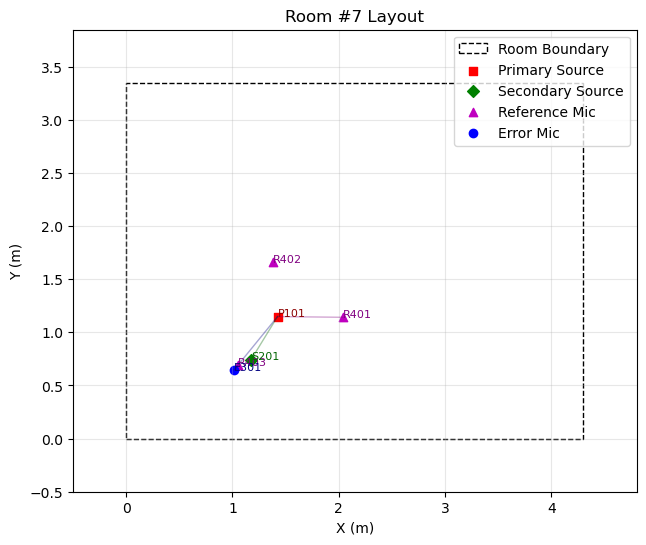

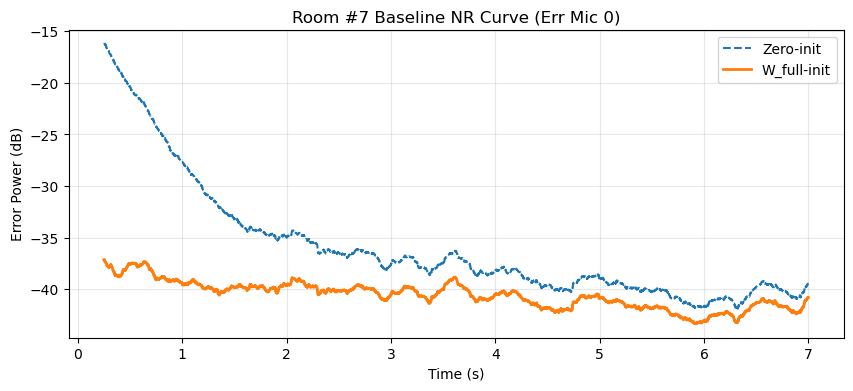

Init NR (dB):
  Zero-init: 2.062
  W_full-init: 22.932


In [17]:
# 选择房间并可视化布局 + 基准初始化对比（Zero-init / W_full-init）
cfg_local, mgr, t, x, d, mu_used, sampler = build_manager_from_h5_room(H5_PATH, room_idx)

# 布局图
_ = plot_layout_with_labels(
    mgr,
    source_ids=np.asarray(sampler.source_id, dtype=int).reshape(-1),
    ref_ids=sampler.ref_ids,
    sec_ids=sampler.sec_ids,
    err_ids=sampler.err_ids,
    title=f"Room #{room_idx} Layout",
)
plt.show()

# Zero-init
e_zero = run_fxlms_with_init(cfg_local, mgr, t, x, d, w_init=None, mu_used=mu_used)

# W_full-init
w_full_room = w_full_all[room_idx]
e_wfull = run_fxlms_with_init(cfg_local, mgr, t, x, d, w_init=w_full_room, mu_used=mu_used)

plot_room_curves(
    cfg_local=cfg_local,
    t=t,
    e_zero=e_zero,
    e_wfull=e_wfull,
    e_ai=None,
    title=f"Room #{room_idx} Baseline NR Curve (Err Mic 0)",
)


def init_nr_db(d_sig, e_sig, fs, early_s=0.25):
    n = min(len(d_sig), len(e_sig))
    m = min(n, max(8, int(fs * early_s)))
    d_pow = float(np.mean(d_sig[:m, 0] ** 2)) + 1e-12
    e_pow = float(np.mean(e_sig[:m, 0] ** 2)) + 1e-12
    return 10.0 * np.log10(d_pow / e_pow)

print("Init NR (dB):")
print("  Zero-init:", round(init_nr_db(d, e_zero, cfg_local.fs), 3))
print("  W_full-init:", round(init_nr_db(d, e_wfull, cfg_local.fs), 3))

## 第二部分：外部实验结果同步与训练历史可视化

本部分只做外部结果同步，不在 notebook 内重新训练：
- 从外部实验目录读取每个 seed 的 train/eval 结果
- 自动发现并展示全部 seed
- 用 history.csv 可视化 train/val loss
- 用 eval summary 展示 seed 级 improvement 指标

In [18]:
# 外部实验结果同步（单一数据源 + strict 指标兼容筛选）

def _safe_metric(v: Any) -> float:
    try:
        return float(v)
    except Exception:
        return float("nan")


def _extract_strict_metrics(eval_summary: dict[str, Any]) -> dict[str, Any]:
    imp = eval_summary.get("improvement_gate", {})
    if isinstance(imp, dict) and ("gap_db" in imp) and ("sample_6db_pass_rate" in imp):
        early = _safe_metric(imp.get("early_gain_db_mean", np.nan))
        gap = _safe_metric(imp.get("gap_db", np.nan))
        sample6 = _safe_metric(imp.get("sample_6db_pass_rate", np.nan))
        return {
            "compatible": np.isfinite(gap) and np.isfinite(sample6),
            "early_gain_db_mean": early,
            "improvement_gap_db": gap,
            "sample_6db_pass_rate": sample6,
            "improvement_pass": bool(imp.get("pass", False)),
            "source": "improvement_gate",
        }

    warm = eval_summary.get("warmstart_metrics", {})
    if isinstance(warm, dict) and ("improvement_gap_db" in warm) and ("sample_6db_pass_rate" in warm):
        early = _safe_metric(warm.get("early_gain_db_mean", np.nan))
        gap = _safe_metric(warm.get("improvement_gap_db", np.nan))
        sample6 = _safe_metric(warm.get("sample_6db_pass_rate", np.nan))
        return {
            "compatible": np.isfinite(gap) and np.isfinite(sample6),
            "early_gain_db_mean": early,
            "improvement_gap_db": gap,
            "sample_6db_pass_rate": sample6,
            "improvement_pass": bool(np.isfinite(gap) and (gap >= 0.0)),
            "source": "warmstart_metrics",
        }

    return {
        "compatible": False,
        "early_gain_db_mean": float("nan"),
        "improvement_gap_db": float("nan"),
        "sample_6db_pass_rate": float("nan"),
        "improvement_pass": False,
        "source": "none",
    }


def _collect_compatible_eval(cfg_dir: Path) -> list[tuple[Path, dict[str, Any], dict[str, Any]]]:
    rows: list[tuple[Path, dict[str, Any], dict[str, Any]]] = []
    for p in sorted(cfg_dir.glob("seed_*/eval/summary.json")):
        try:
            eval_summary = json.loads(p.read_text(encoding="utf-8"))
        except Exception:
            continue
        metrics = _extract_strict_metrics(eval_summary)
        if bool(metrics["compatible"]):
            rows.append((p, eval_summary, metrics))
    return rows


def _resolve_sync_root_and_config(
    explicit_root: Path | None,
    explicit_config: str | None,
    candidates: list[Path],
) -> tuple[Path, Path, list[tuple[Path, dict[str, Any], dict[str, Any]]]]:
    roots_to_scan = [Path(explicit_root)] if explicit_root is not None else [Path(c) for c in candidates]

    for root in roots_to_scan:
        if not root.exists():
            continue

        config_dirs = sorted([p for p in root.iterdir() if p.is_dir()])
        if explicit_config is not None:
            cfg_dir = root / str(explicit_config)
            if not cfg_dir.exists():
                continue
            compat = _collect_compatible_eval(cfg_dir)
            if compat:
                return root, cfg_dir, compat
            continue

        scored = []
        for cfg_dir in config_dirs:
            compat = _collect_compatible_eval(cfg_dir)
            if compat:
                scored.append((len(compat), cfg_dir.name, cfg_dir, compat))

        if scored:
            scored.sort(key=lambda x: (-x[0], x[1]))
            _, _, best_cfg_dir, best_compat = scored[0]
            return root, best_cfg_dir, best_compat

    if explicit_root is not None:
        raise RuntimeError(
            "Given SYNC_RESULTS_ROOT_OVERRIDE has no strict-metric-compatible eval summaries. "
            "Please run strict eval or point to another experiment root."
        )

    cand_text = "\n".join(str(p) for p in candidates)
    raise RuntimeError(
        "No strict-metric-compatible eval summaries found in candidate roots:\n" + cand_text
    )


SYNC_RESULTS_ROOT, selected_config_dir, compatible_eval = _resolve_sync_root_and_config(
    explicit_root=SYNC_RESULTS_ROOT_OVERRIDE,
    explicit_config=SYNC_CONFIG_NAME,
    candidates=EXPERIMENT_ROOT_CANDIDATES,
)
SYNC_CONFIG_NAME = selected_config_dir.name

synced_rows: list[dict[str, Any]] = []
for p, eval_summary, metrics in compatible_eval:
    seed_dir = p.parent.parent
    seed_name = seed_dir.name
    seed_default = -1
    if seed_name.startswith("seed_"):
        try:
            seed_default = int(seed_name.split("_", 1)[1])
        except Exception:
            seed_default = -1
    seed = int(eval_summary.get("seed", seed_default))

    train_summary_path = seed_dir / "train" / "summary.json"
    history_path = seed_dir / "train" / "history.csv"

    train_summary: dict[str, Any] = {}
    if train_summary_path.exists():
        train_summary = json.loads(train_summary_path.read_text(encoding="utf-8"))

    checkpoint_raw = str(eval_summary.get("checkpoint", "")).strip()
    checkpoint_path = seed_dir / "train" / "final_hybrid_deep_fxlms.pt"
    if checkpoint_raw:
        cp = Path(checkpoint_raw)
        checkpoint_path = cp if cp.is_absolute() else (ROOT / cp)

    synced_rows.append(
        {
            "seed": seed,
            "eval_file": p,
            "train_summary_path": train_summary_path,
            "history_path": history_path,
            "checkpoint_path": checkpoint_path,
            "eval_summary": eval_summary,
            "train_summary": train_summary,
            "early_gain_db_mean": float(metrics["early_gain_db_mean"]),
            "improvement_gap_db": float(metrics["improvement_gap_db"]),
            "sample_6db_pass_rate": float(metrics["sample_6db_pass_rate"]),
            "improvement_pass": bool(metrics["improvement_pass"]),
            "metrics_source": str(metrics["source"]),
            "gate_status_legacy": str(eval_summary.get("gate_status", "")),
        }
    )

synced_rows = sorted(synced_rows, key=lambda r: r["seed"])
if not synced_rows:
    raise RuntimeError("synced_rows is empty")

print("=== External Sync Source ===")
print("SYNC_RESULTS_ROOT:", SYNC_RESULTS_ROOT)
print("SYNC_CONFIG_NAME:", SYNC_CONFIG_NAME)
print("Discovered seeds:", [r["seed"] for r in synced_rows])

print("\n=== Synced Eval Overview ===")
for r in synced_rows:
    print(
        f"seed={r['seed']:>3} | "
        f"early_gain={r['early_gain_db_mean']:.4f} dB | "
        f"gap={r['improvement_gap_db']:.4f} dB | "
        f"sample_6db={r['sample_6db_pass_rate']:.3f} | "
        f"improvement_pass={r['improvement_pass']} | "
        f"source={r['metrics_source']} | legacy_status={r['gate_status_legacy']}"
    )

=== External Sync Source ===
SYNC_RESULTS_ROOT: Z:\anc\distributed_anc_sim_py\python_impl\python_scripts\_tmp_smoke_canon_l123_s3
SYNC_CONFIG_NAME: b01_ri_cross_freq_lam1e3_b32
Discovered seeds: [7, 42, 123]

=== Synced Eval Overview ===
seed=  7 | early_gain=17.8768 dB | gap=11.8768 dB | sample_6db=1.000 | improvement_pass=True | source=improvement_gate | legacy_status=failed
seed= 42 | early_gain=17.1278 dB | gap=11.1278 dB | sample_6db=1.000 | improvement_pass=True | source=improvement_gate | legacy_status=failed
seed=123 | early_gain=17.5988 dB | gap=11.5988 dB | sample_6db=1.000 | improvement_pass=True | source=improvement_gate | legacy_status=failed


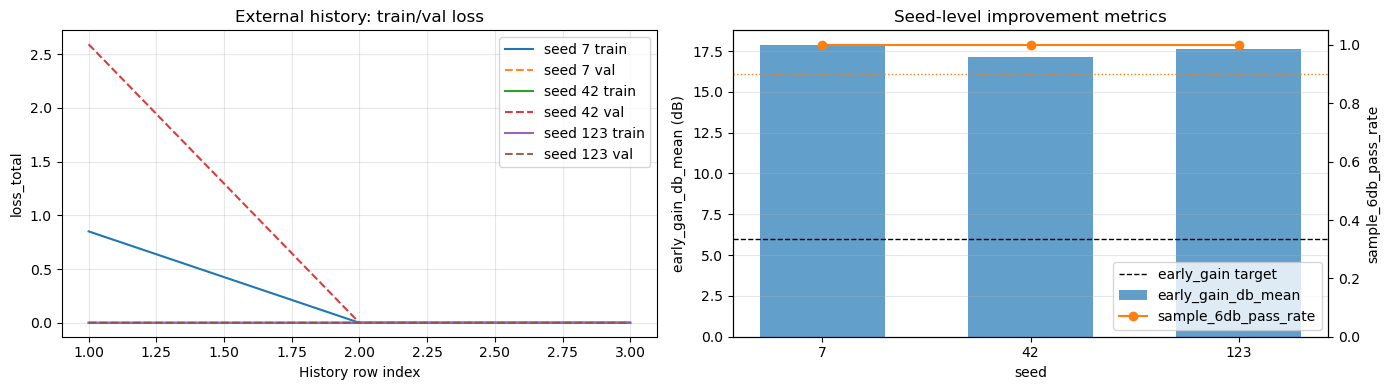

all synced seeds have history.csv


In [19]:
# 训练历史可视化（history.csv）+ seed 级 improvement 指标概览

def _safe_float(x: Any) -> float:
    try:
        return float(x)
    except Exception:
        return float("nan")


def load_history_rows(history_path: Path) -> list[dict[str, Any]]:
    if not history_path.exists():
        return []

    rows: list[dict[str, Any]] = []
    with history_path.open("r", encoding="utf-8", newline="") as f:
        reader = csv.DictReader(f)
        for raw in reader:
            row = dict(raw)
            row["stage"] = int(_safe_float(raw.get("stage", 0)))
            row["level"] = int(_safe_float(raw.get("level", 0)))
            row["epoch"] = int(_safe_float(raw.get("epoch", 0)))
            row["train_loss_total"] = _safe_float(raw.get("train_loss_total", np.nan))
            row["val_loss_total"] = _safe_float(raw.get("val_loss_total", np.nan))
            row["train_nr_db"] = _safe_float(raw.get("train_nr_db", np.nan))
            row["val_nr_db"] = _safe_float(raw.get("val_nr_db", np.nan))
            rows.append(row)
    return rows


history_by_seed: dict[int, list[dict[str, Any]]] = {}
missing_history: list[int] = []
for row in synced_rows:
    hist = load_history_rows(Path(row["history_path"]))
    if hist:
        history_by_seed[int(row["seed"])] = hist
    else:
        missing_history.append(int(row["seed"]))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

for row in synced_rows:
    seed = int(row["seed"])
    hist = history_by_seed.get(seed, [])
    if not hist:
        continue
    steps = np.arange(1, len(hist) + 1, dtype=np.int64)
    train_loss = np.asarray([h["train_loss_total"] for h in hist], dtype=float)
    val_loss = np.asarray([h["val_loss_total"] for h in hist], dtype=float)
    ax[0].plot(steps, train_loss, label=f"seed {seed} train")
    ax[0].plot(steps, val_loss, linestyle="--", alpha=0.9, label=f"seed {seed} val")

ax[0].set_title("External history: train/val loss")
ax[0].set_xlabel("History row index")
ax[0].set_ylabel("loss_total")
ax[0].grid(alpha=0.3)
if len(ax[0].lines) <= 12:
    ax[0].legend(loc="best")

seed_labels = [str(int(r["seed"])) for r in synced_rows]
x = np.arange(len(seed_labels), dtype=float)
early_vals = np.asarray([float(r["early_gain_db_mean"]) for r in synced_rows], dtype=float)
sample_vals = np.asarray([float(r["sample_6db_pass_rate"]) for r in synced_rows], dtype=float)

ax[1].bar(x, early_vals, width=0.6, alpha=0.7, label="early_gain_db_mean")
ax[1].axhline(MIN_IMPROVEMENT_DB, color="k", linestyle="--", linewidth=1, label="early_gain target")
ax[1].set_xticks(x)
ax[1].set_xticklabels(seed_labels)
ax[1].set_xlabel("seed")
ax[1].set_ylabel("early_gain_db_mean (dB)")
ax[1].set_title("Seed-level improvement metrics")
ax[1].grid(axis="y", alpha=0.3)

ax1b = ax[1].twinx()
ax1b.plot(x, sample_vals, marker="o", color="tab:orange", label="sample_6db_pass_rate")
ax1b.axhline(MONITOR_SAMPLE_6DB_TARGET, color="tab:orange", linestyle=":", linewidth=1)
ax1b.set_ylabel("sample_6db_pass_rate")
ax1b.set_ylim(0.0, 1.05)

h1, l1 = ax[1].get_legend_handles_labels()
h2, l2 = ax1b.get_legend_handles_labels()
ax[1].legend(h1 + h2, l1 + l2, loc="lower right")

plt.tight_layout()
plt.show()

if missing_history:
    print("history.csv missing for seeds:", missing_history)
else:
    print("all synced seeds have history.csv")

## 第三部分：测试可视化与全局统计（来自同一外部结果源）

本部分完成：
- 从同步结果中选定一个 seed 的 checkpoint 做房间级曲线对比（AI-init / W_full-init / Zero-init）
- 用同步得到的全部 seed eval summary 做全局统计（improvement_gap_db、early_gain_db_mean、sample_6db_pass_rate）

Room visualization seed: 7
AI checkpoint: Z:\anc\distributed_anc_sim_py\python_impl\python_scripts\_tmp_smoke_canon_l123_s3\b01_ri_cross_freq_lam1e3_b32\seed_7\train\final_hybrid_deep_fxlms.pt
checkpoint exists: True
{'use_canonical_prior': True, 'canonical_prior_scale': 1.0, 'residual_head_zero_init': True, 'use_path_features': False}
Room 7:


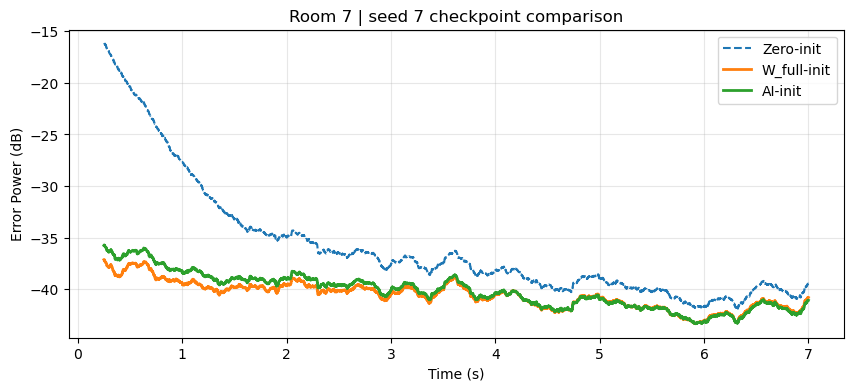

Room 8:


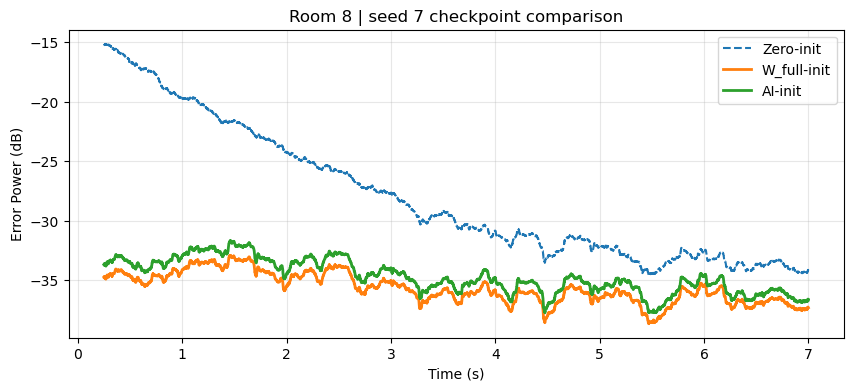

Room 15:


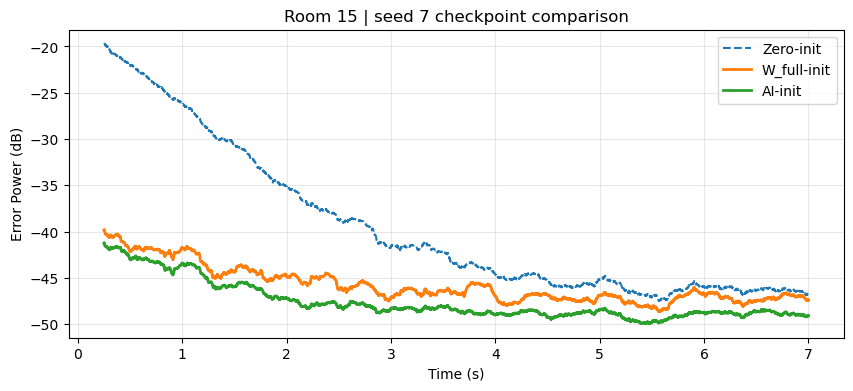

In [20]:
# 房间级对比：使用同步外部 checkpoint（AI-init vs W_full-init vs Zero-init）
show_rooms = test_level_idx[: min(3, len(test_level_idx))]
if len(show_rooms) == 0:
    raise RuntimeError("No rooms available in test_level_idx")

if SYNC_SEED_FOR_ROOM_VIS is None:
    finite_rows = [r for r in synced_rows if np.isfinite(float(r["improvement_gap_db"]))]
    vis_row = max(finite_rows, key=lambda r: float(r["improvement_gap_db"])) if finite_rows else synced_rows[0]
else:
    matched = [r for r in synced_rows if int(r["seed"]) == int(SYNC_SEED_FOR_ROOM_VIS)]
    if not matched:
        raise RuntimeError(f"SYNC_SEED_FOR_ROOM_VIS={SYNC_SEED_FOR_ROOM_VIS} not found in synced_rows")
    vis_row = matched[0]

AI_CHECKPOINT_PATH = Path(vis_row["checkpoint_path"])
w_ai_rooms, vis_train_args = load_ai_model_and_predict(
    checkpoint_path=AI_CHECKPOINT_PATH,
    h5_path=H5_PATH,
    room_indices=np.asarray(show_rooms, dtype=np.int64),
)

print("Room visualization seed:", vis_row["seed"])
print("AI checkpoint:", AI_CHECKPOINT_PATH)
print("checkpoint exists:", AI_CHECKPOINT_PATH.exists())
print(
    {
        "use_canonical_prior": bool(vis_train_args.get("use_canonical_prior", False)),
        "canonical_prior_scale": float(vis_train_args.get("canonical_prior_scale", 1.0)),
        "residual_head_zero_init": bool(vis_train_args.get("residual_head_zero_init", False)),
        "use_path_features": bool(vis_train_args.get("use_path_features", False)),
    }
)

for ridx, w_ai in zip(show_rooms.tolist(), w_ai_rooms):
    cfg_local, mgr, t, x, d, mu_used, sampler = build_manager_from_h5_room(H5_PATH, int(ridx))
    e_zero = run_fxlms_with_init(cfg_local, mgr, t, x, d, w_init=None, mu_used=mu_used)
    e_wfull = run_fxlms_with_init(cfg_local, mgr, t, x, d, w_init=w_full_all[int(ridx)], mu_used=mu_used)
    e_ai = run_fxlms_with_init(cfg_local, mgr, t, x, d, w_init=w_ai[None, :, :], mu_used=mu_used)

    print(f"Room {ridx}:")
    plot_room_curves(
        cfg_local=cfg_local,
        t=t,
        e_zero=e_zero,
        e_wfull=e_wfull,
        e_ai=e_ai,
        title=f"Room {ridx} | seed {vis_row['seed']} checkpoint comparison",
    )

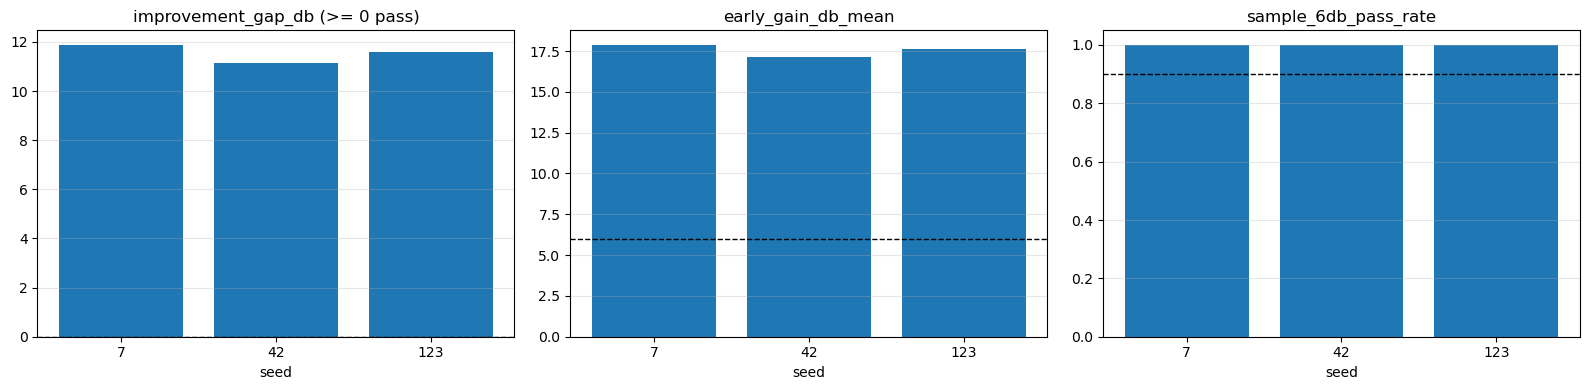

=== Per-seed summary ===
seed=  7 | early_gain=17.8768 dB | gap=11.8768 dB | sample_6db=1.000 | legacy=failed
seed= 42 | early_gain=17.1278 dB | gap=11.1278 dB | sample_6db=1.000 | legacy=failed
seed=123 | early_gain=17.5988 dB | gap=11.5988 dB | sample_6db=1.000 | legacy=failed

=== Aggregate ===
improvement_pass_all: True
improvement_gap_db_mean: 11.534474858887373
sample_6db_pass_rate_mean: 1.0


In [ ]:
# 全 seed 统计对比（来自同步 eval summary）
seed_labels = [str(int(r["seed"])) for r in synced_rows]
seeds = np.asarray([int(r["seed"]) for r in synced_rows], dtype=np.int64)
improvement_gaps = np.asarray([float(r["improvement_gap_db"]) for r in synced_rows], dtype=float)
early_gains = np.asarray([float(r["early_gain_db_mean"]) for r in synced_rows], dtype=float)
sample_6db_rates = np.asarray([float(r["sample_6db_pass_rate"]) for r in synced_rows], dtype=float)
legacy_status = [str(r["gate_status_legacy"]) for r in synced_rows]

x = np.arange(len(seeds), dtype=float)

fig, ax = plt.subplots(1, 3, figsize=(16, 4))

ax[0].bar(x, improvement_gaps)
ax[0].axhline(0.0, color="k", linestyle="--", linewidth=1)
ax[0].set_xticks(x)
ax[0].set_xticklabels(seed_labels)
ax[0].set_title("improvement_gap_db (>= 0 pass)")
ax[0].set_xlabel("seed")
ax[0].grid(axis="y", alpha=0.3)

ax[1].bar(x, early_gains)
ax[1].axhline(MIN_IMPROVEMENT_DB, color="k", linestyle="--", linewidth=1)
ax[1].set_xticks(x)
ax[1].set_xticklabels(seed_labels)
ax[1].set_title("early_gain_db_mean")
ax[1].set_xlabel("seed")
ax[1].grid(axis="y", alpha=0.3)

ax[2].bar(x, sample_6db_rates)
ax[2].axhline(MONITOR_SAMPLE_6DB_TARGET, color="k", linestyle="--", linewidth=1)
ax[2].set_xticks(x)
ax[2].set_xticklabels(seed_labels)
ax[2].set_ylim(0.0, 1.05)
ax[2].set_title("sample_6db_pass_rate")
ax[2].set_xlabel("seed")
ax[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

improvement_pass_all = all(bool(r["improvement_pass"]) for r in synced_rows)
improvement_gap_mean = float(np.nanmean(improvement_gaps))
sample_6db_pass_rate_mean = float(np.nanmean(sample_6db_rates))

print("=== Per-seed summary ===")
for seed, eg, gap, s6, ls in zip(seeds.tolist(), early_gains.tolist(), improvement_gaps.tolist(), sample_6db_rates.tolist(), legacy_status):
    print(
        f"seed={seed:>3} | early_gain={eg:.4f} dB | gap={gap:.4f} dB | "
        f"sample_6db={s6:.3f} | legacy={ls}"
    )

print("\n=== Aggregate ===")
print("improvement_pass_all:", improvement_pass_all)
print("improvement_gap_db_mean:", improvement_gap_mean)
print("sample_6db_pass_rate_mean:", sample_6db_pass_rate_mean)

## 第四部分：Split 硬审计与 Notebook Gate

本部分执行最终发布前硬检查：
- split 审计：验证 train/val/test 三者严格互斥，且外部 train/eval summary 的 split 计数与 notebook 参考切分一致
- gate 审计：要求 improvement_gate 全部 seed 通过，且 sample_6db_pass_rate 均值达到监控目标
- 任一条件失败时直接 assert，视为未通过

In [22]:
# Split 硬审计 + Notebook Gate（最终断言）
if not synced_rows:
    raise RuntimeError("synced_rows is empty, run section 2 first")

all_idx_ref = np.arange(image_order.shape[0], dtype=np.int64)

# 1) 先检查 notebook 参考 split（用于可视化部分）本身是互斥的
train_idx_ref, val_idx_ref, test_idx_ref = split_indices_train_val_test(
    indices=all_idx_ref,
    val_frac=VAL_FRAC,
    test_frac=TEST_FRAC,
    seed=SPLIT_SEED,
)

intersections_ref = {
    "train_val": int(np.intersect1d(train_idx_ref, val_idx_ref).size),
    "train_test": int(np.intersect1d(train_idx_ref, test_idx_ref).size),
    "val_test": int(np.intersect1d(val_idx_ref, test_idx_ref).size),
}
if any(v != 0 for v in intersections_ref.values()):
    raise AssertionError(f"Notebook reference split disjointness failed: {intersections_ref}")

# 2) 审计每个 seed 的 train/eval summary：逐 seed 重建 split 并核对
split_audit_errors: list[str] = []
seen_split_seeds: list[int] = []

for row in synced_rows:
    run_seed = int(row["seed"])
    train_summary = row["train_summary"]
    eval_summary = row["eval_summary"]

    global_split = train_summary.get("global_split", {}) if isinstance(train_summary, dict) else {}
    if not global_split:
        split_audit_errors.append(f"seed={run_seed}: missing train summary global_split")
        continue

    split_seed = int(global_split.get("seed", -1))
    if split_seed < 0:
        split_audit_errors.append(f"seed={run_seed}: invalid global_split.seed={split_seed}")
        continue
    seen_split_seeds.append(split_seed)

    val_frac_run = float(train_summary.get("val_frac", VAL_FRAC))
    test_frac_run = float(train_summary.get("test_frac", TEST_FRAC))

    tr_i, va_i, te_i = split_indices_train_val_test(
        indices=all_idx_ref,
        val_frac=val_frac_run,
        test_frac=test_frac_run,
        seed=split_seed,
    )

    intersections_run = {
        "train_val": int(np.intersect1d(tr_i, va_i).size),
        "train_test": int(np.intersect1d(tr_i, te_i).size),
        "val_test": int(np.intersect1d(va_i, te_i).size),
    }
    if any(v != 0 for v in intersections_run.values()):
        split_audit_errors.append(f"seed={run_seed}: reconstructed split not disjoint: {intersections_run}")

    expected_counts_run = {
        "num_total": int(all_idx_ref.size),
        "num_train": int(tr_i.size),
        "num_val": int(va_i.size),
        "num_test": int(te_i.size),
    }
    for k in ["num_total", "num_train", "num_val", "num_test"]:
        got = int(global_split.get(k, -1))
        if got != int(expected_counts_run[k]):
            split_audit_errors.append(
                f"seed={run_seed}: global_split.{k}={got} != reconstructed {expected_counts_run[k]}"
            )

    eval_split = str(eval_summary.get("eval_split", "")).strip().lower()
    if eval_split != "test":
        split_audit_errors.append(f"seed={run_seed}: eval_split={eval_split} (expected test)")

    split_sizes = eval_summary.get("split_sizes", {}) if isinstance(eval_summary, dict) else {}
    eval_base = int(split_sizes.get("eval_base", -1))
    if eval_base != int(expected_counts_run["num_test"]):
        split_audit_errors.append(
            f"seed={run_seed}: split_sizes.eval_base={eval_base} != reconstructed num_test={expected_counts_run['num_test']}"
        )

print("=== Split Audit ===")
print("reference split seed:", SPLIT_SEED)
print("reference intersections:", intersections_ref)
print("checked seeds:", [int(r["seed"]) for r in synced_rows])
print("run split seeds:", seen_split_seeds)

unique_split_seeds = sorted(set(seen_split_seeds))
if len(unique_split_seeds) > 1:
    print("warning: multiple split seeds detected across runs:", unique_split_seeds)

if split_audit_errors:
    print("split_audit_errors:")
    for err in split_audit_errors:
        print(" -", err)
    raise AssertionError("Split audit failed; fix split leakage/inconsistency before acceptance.")

print("split_audit_pass = True")

# 3) Notebook Gate（统一基于 synced_rows）
improvement_pass_all = all(bool(r["improvement_pass"]) for r in synced_rows)
improvement_gap_mean = float(np.nanmean([float(r["improvement_gap_db"]) for r in synced_rows]))
sample_6db_pass_rate_mean = float(np.nanmean([float(r["sample_6db_pass_rate"]) for r in synced_rows]))

notebook_gate_pass = bool(
    improvement_pass_all
    and np.isfinite(improvement_gap_mean)
    and (improvement_gap_mean >= 0.0)
    and np.isfinite(sample_6db_pass_rate_mean)
    and (sample_6db_pass_rate_mean >= MONITOR_SAMPLE_6DB_TARGET)
)

print("\n=== Notebook Gate ===")
print(f"MIN_IMPROVEMENT_DB = {MIN_IMPROVEMENT_DB:.3f}")
print(f"MONITOR_SAMPLE_6DB_TARGET = {MONITOR_SAMPLE_6DB_TARGET:.3f}")
print(f"improvement_pass_all = {improvement_pass_all}")
print(f"improvement_gap_db_mean = {improvement_gap_mean:.6f}")
print(f"sample_6db_pass_rate_mean = {sample_6db_pass_rate_mean:.6f}")
print(f"NOTEBOOK_GATE_PASS = {notebook_gate_pass}")

if not notebook_gate_pass:
    raise AssertionError(
        "Notebook gate failed: continue training/tuning and re-sync external results until this gate passes."
    )

=== Split Audit ===
reference split seed: 7
reference intersections: {'train_val': 0, 'train_test': 0, 'val_test': 0}
checked seeds: [7, 42, 123]
run split seeds: [7, 42, 123]
split_audit_pass = True

=== Notebook Gate ===
MIN_IMPROVEMENT_DB = 6.000
MONITOR_SAMPLE_6DB_TARGET = 0.900
improvement_pass_all = True
improvement_gap_db_mean = 11.534475
sample_6db_pass_rate_mean = 1.000000
NOTEBOOK_GATE_PASS = True
